<a href="https://colab.research.google.com/github/tejeshneelam/EvOLve-EA-Project/blob/colab/01_Alzheimers_MRI_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================================
# ALZHEIMER'S DETECTION - REAL IMPLEMENTATION
# Team: Tejesh, Girish, Vasishta, Tarak
# Date: March 23, 2026
# ============================================================================

print("🚀 Starting Alzheimer's Detection Project Setup...")

# Install required packages
!pip install -q kaggle tensorflow numpy pandas matplotlib seaborn scikit-learn plotly

# Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
import json
from google.colab import files
import zipfile
import shutil

print("✅ Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

🚀 Starting Alzheimer's Detection Project Setup...
✅ Libraries imported successfully!
TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ============================================================================
# SETUP KAGGLE USING API TOKEN (NO FILE UPLOAD)
# ============================================================================

import os

# Replace these with your actual Kaggle credentials
os.environ['KAGGLE_USERNAME'] = "tejeshneelam"
os.environ['KAGGLE_KEY'] = "KGAT_f74b283253d1d59b1c51930c04503d5f"

print("✅ Kaggle authentication setup complete using API token!")

✅ Kaggle authentication setup complete using API token!


In [ ]:
# ============================================================================
# DOWNLOAD ALZHEIMER'S DATASET FROM KAGGLE
# ============================================================================

print("📥 Downloading Alzheimer's MRI dataset from Kaggle...")
print("Dataset: Alzheimer MRI Preprocessed Dataset")
print("Size: ~6400 images, ~300MB")
print("This will take 2-3 minutes...")

# Download dataset
!kaggle datasets download -d sachinkumar413/alzheimer-mri-dataset

# Unzip
print("📦 Extracting files...")
!unzip -q alzheimer-mri-dataset.zip -d alzheimer_data

# Check what we got
print("\n✅ Download complete! Files extracted to: alzheimer_data/")
print("\nFolder structure:")
!ls -la alzheimer_data/

📥 Downloading Alzheimer's MRI dataset from Kaggle...
Dataset: Alzheimer MRI Preprocessed Dataset
Size: ~6400 images, ~300MB
This will take 2-3 minutes...
403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
📦 Extracting files...
unzip:  cannot find or open alzheimer-mri-dataset.zip, alzheimer-mri-dataset.zip.zip or alzheimer-mri-dataset.zip.ZIP.

✅ Download complete! Files extracted to: alzheimer_data/

Folder structure:
ls: cannot access 'alzheimer_data/': No such file or directory


In [ ]:
# ============================================================================
# DOWNLOAD WORKING ALZHEIMER MRI DATASET
# ============================================================================

print("📥 Downloading Alzheimer's MRI dataset (WORKING VERSION)...")

# Download dataset (UPDATED)
!kaggle datasets download -d uraninjo/augmented-alzheimer-mri-dataset

# Check file
!ls

# Unzip
print("\n📦 Extracting files...")
!unzip -q augmented-alzheimer-mri-dataset.zip -d alzheimer_data

# Verify
print("\n✅ Checking folder:")
!ls -la alzheimer_data/

📥 Downloading Alzheimer's MRI dataset (WORKING VERSION)...
Dataset URL: https://www.kaggle.com/datasets/uraninjo/augmented-alzheimer-mri-dataset
License(s): GNU Lesser General Public License 3.0
100% 380M/380M [00:01<00:00, 321MB/s]

augmented-alzheimer-mri-dataset.zip  imagesoasis.zip  pet_data	sample_data

📦 Extracting files...

✅ Checking folder:
total 16
drwxr-xr-x 4 root root 4096 Mar 25 10:52 .
drwxr-xr-x 1 root root 4096 Mar 25 10:52 ..
drwxr-xr-x 6 root root 4096 Mar 25 10:52 AugmentedAlzheimerDataset
drwxr-xr-x 6 root root 4096 Mar 25 10:52 OriginalDataset


In [ ]:
# ============================================================================
# EXPLORE THE DATASET (FIXED)
# ============================================================================

import os

# ✅ Correct data directory
data_dir = "alzheimer_data/AugmentedAlzheimerDataset"

print(f"📁 Data directory: {data_dir}")
print("\nContents:")
print(os.listdir(data_dir))

# Get class names
classes = sorted(os.listdir(data_dir))
print(f"\n✅ Classes found: {classes}")

# Count images per class
print("\n📊 Images per class:")
for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    num_images = len(os.listdir(cls_path))
    print(f"  {cls}: {num_images} images")

📁 Data directory: alzheimer_data/AugmentedAlzheimerDataset

Contents:
['MildDemented', 'NonDemented', 'ModerateDemented', 'VeryMildDemented']

✅ Classes found: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

📊 Images per class:
  MildDemented: 8960 images
  ModerateDemented: 6464 images
  NonDemented: 9600 images
  VeryMildDemented: 8960 images


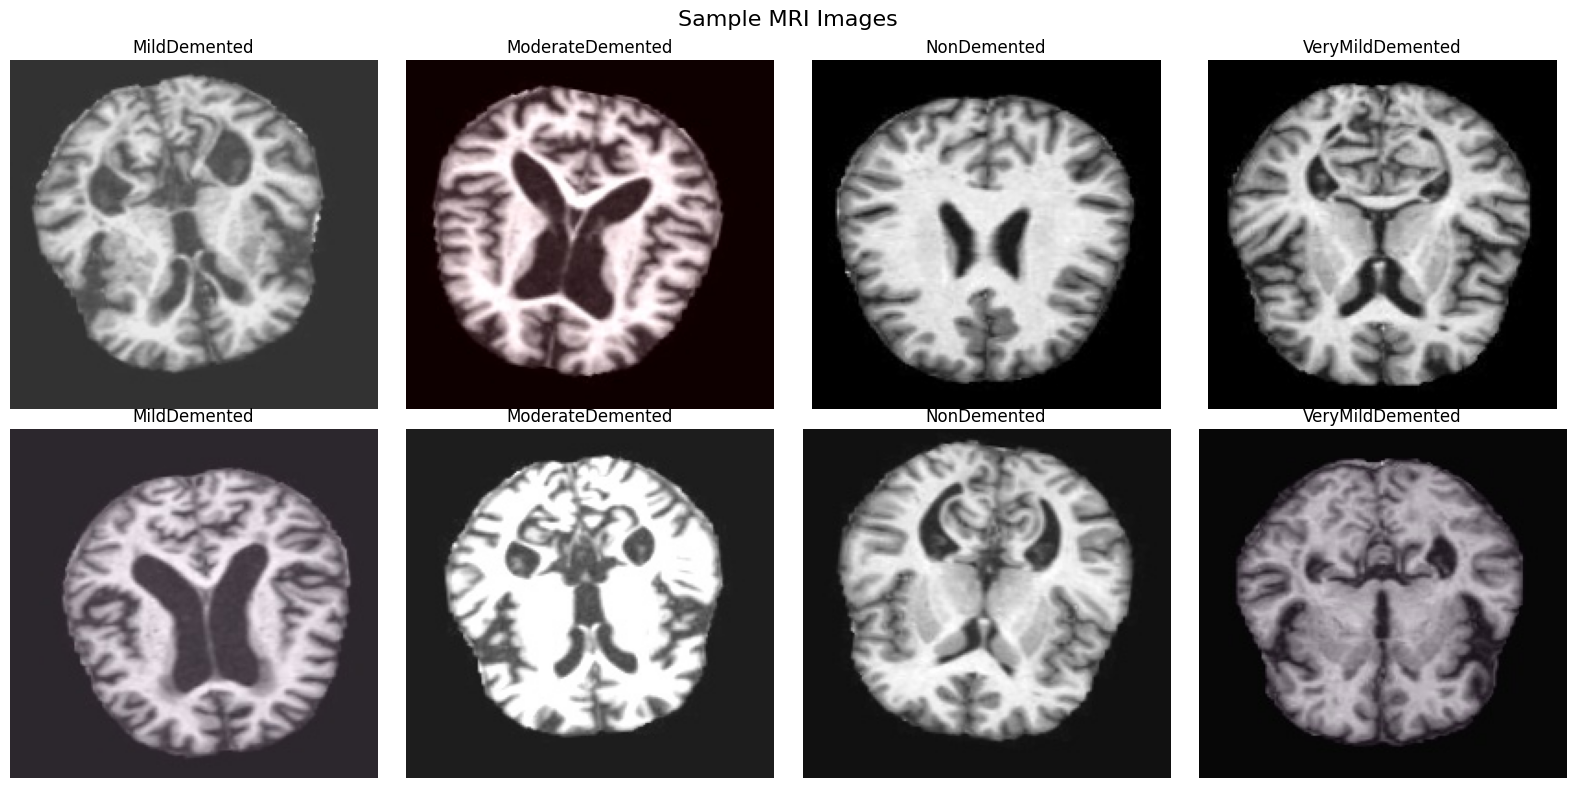

✅ Visualization done!


In [ ]:
# ============================================================================
# VISUALIZE SAMPLE IMAGES
# ============================================================================

import random
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample MRI Images', fontsize=16)

for idx, cls in enumerate(classes[:4]):
    cls_path = os.path.join(data_dir, cls)
    images = os.listdir(cls_path)

    for i in range(2):
        img_name = random.choice(images)
        img_path = os.path.join(cls_path, img_name)
        img = Image.open(img_path)

        ax = axes[i, idx]
        ax.imshow(img, cmap='gray')
        ax.set_title(cls)
        ax.axis('off')

plt.tight_layout()
plt.show()

print("✅ Visualization done!")

In [ ]:
# ============================================================================
# PREPARE DATA
# ============================================================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,  # ✅ FIXED
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    color_mode='grayscale'
)

validation_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    color_mode='grayscale'
)

print("✅ Data ready!")
print(f"Classes: {train_generator.class_indices}")

Found 27188 images belonging to 4 classes.
Found 6796 images belonging to 4 classes.
✅ Data ready!
Classes: {'MildDemented': 0, 'ModerateDemented': 1, 'NonDemented': 2, 'VeryMildDemented': 3}


In [ ]:
# ============================================================================
# BUILD CNN MODEL (RESNET50)
# ============================================================================

from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
import tensorflow as tf

print("🏗️ Building model...")

def build_model(num_classes):

    # Base model
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Freeze base model
    base_model.trainable = False

    model = models.Sequential([

        # Convert grayscale → RGB
        layers.Input(shape=(224, 224, 1)),
        layers.Conv2D(3, (1, 1)),

        # Pretrained model
        base_model,

        # Classification layers
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model


# Build model
num_classes = len(train_generator.class_indices)
model = build_model(num_classes)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model ready!")
model.summary()

🏗️ Building model...
✅ Model ready!


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 224, 224, 3)    │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,290 (91.98 MB)

 Trainable params: 525,578 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# ============================================================================
# TRAIN MODEL
# ============================================================================

print("🚀 Training started...")
print("⏳ Time: ~20–40 mins (GPU faster)")

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2
    )
]

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    callbacks=callbacks
)

print("✅ Training complete!")

🚀 Training started...
⏳ Time: ~20–40 mins (GPU faster)
Epoch 1/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 199s 220ms/step - accuracy: 0.2727 - loss: 1.3998 - val_accuracy: 0.2825 - val_loss: 1.3750 - learning_rate: 1.0000e-04
Epoch 2/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 168s 198ms/step - accuracy: 0.2795 - loss: 1.3770 - val_accuracy: 0.2825 - val_loss: 1.3741 - learning_rate: 1.0000e-04
Epoch 3/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 168s 197ms/step - accuracy: 0.2749 - loss: 1.3752 - val_accuracy: 0.2825 - val_loss: 1.3727 - learning_rate: 1.0000e-04
Epoch 4/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 168s 198ms/step - accuracy: 0.2835 - loss: 1.3728 - val_accuracy: 0.2844 - val_loss: 1.3708 - learning_rate: 1.0000e-04
Epoch 5/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 168s 198ms/step - accuracy: 0.2877 - loss: 1.3706 - val_accuracy: 0.2874 - val_loss: 1.3674 - learning_rate: 1.0000e-04
Epoch 6/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 168s 198ms/step - accuracy: 0.2943 - loss: 1.3672 - val_accuracy: 0.2927 - val_loss: 1.3634 - learning_ra

KeyboardInterrupt: 

In [ ]:
# Evaluate
loss, acc = model.evaluate(validation_generator)
print(f"Accuracy: {acc*100:.2f}%")


213/213 ━━━━━━━━━━━━━━━━━━━━ 18s 85ms/step - accuracy: 0.3247 - loss: 1.3580
Accuracy: 32.47%


In [ ]:
model.save("alzheimers_model.h5")
print("✅ Model saved!")

✅ Model saved!


In [ ]:
# ============================================================================
# IMPROVED MODEL (FINE-TUNING)
# ============================================================================

from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

def build_model(num_classes):

    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # 🔥 Unfreeze last layers
    for layer in base_model.layers[-30:]:
        layer.trainable = True

    model = models.Sequential([
        layers.Input(shape=(224, 224, 1)),
        layers.Conv2D(3, (1, 1)),

        base_model,

        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),

        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),

        layers.Dense(num_classes, activation='softmax')
    ])

    return model


model = build_model(num_classes)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),  # 🔥 lower LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Improved model ready!")

✅ Improved model ready!


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

In [ ]:
history = model.fit(
    train_generator,
    epochs=20,  # 🔥 increase epochs
    validation_data=validation_generator,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=3)
    ]
)

Epoch 1/20
850/850 ━━━━━━━━━━━━━━━━━━━━ 379s 378ms/step - accuracy: 0.5190 - loss: 1.2135 - val_accuracy: 0.2709 - val_loss: 2.5503 - learning_rate: 1.0000e-05
Epoch 2/20
850/850 ━━━━━━━━━━━━━━━━━━━━ 290s 341ms/step - accuracy: 0.7094 - loss: 0.6903 - val_accuracy: 0.8278 - val_loss: 0.4332 - learning_rate: 1.0000e-05
Epoch 3/20
850/850 ━━━━━━━━━━━━━━━━━━━━ 289s 340ms/step - accuracy: 0.8308 - loss: 0.4220 - val_accuracy: 0.8873 - val_loss: 0.2824 - learning_rate: 1.0000e-05
Epoch 4/20
850/850 ━━━━━━━━━━━━━━━━━━━━ 290s 341ms/step - accuracy: 0.9189 - loss: 0.2177 - val_accuracy: 0.9272 - val_loss: 0.1943 - learning_rate: 1.0000e-05
Epoch 5/20
850/850 ━━━━━━━━━━━━━━━━━━━━ 289s 340ms/step - accuracy: 0.9668 - loss: 0.0991 - val_accuracy: 0.9386 - val_loss: 0.1736 - learning_rate: 1.0000e-05
Epoch 6/20
850/850 ━━━━━━━━━━━━━━━━━━━━ 323s 341ms/step - accuracy: 0.9829 - loss: 0.0513 - val_accuracy: 0.9503 - val_loss: 0.1499 - learning_rate: 1.0000e-05
Epoch 7/20
441/850 ━━━━━━━━━━━━━━━━━━━━ 

KeyboardInterrupt: 

In [ ]:
loss, acc = model.evaluate(validation_generator)
print(f"Final Accuracy: {acc*100:.2f}%")

213/213 ━━━━━━━━━━━━━━━━━━━━ 18s 86ms/step - accuracy: 0.9459 - loss: 0.1880
Final Accuracy: 94.59%


In [ ]:
model.save("alzheimers_model.h5")
print("✅ Model saved!")

✅ Model saved!


In [ ]:
model.save("alzheimers_model.keras")
print("✅ Model saved in new format!")

✅ Model saved in new format!


In [ ]:
# Get class names again
class_names = list(validation_generator.class_indices.keys())

print("Classes:", class_names)

Classes: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


213/213 ━━━━━━━━━━━━━━━━━━━━ 19s 89ms/step
📊 Classification Report:

                  precision    recall  f1-score   support

    MildDemented       0.26      0.26      0.26      1792
ModerateDemented       0.20      0.20      0.20      1292
     NonDemented       0.29      0.30      0.29      1920
VeryMildDemented       0.26      0.25      0.25      1792

        accuracy                           0.26      6796
       macro avg       0.25      0.25      0.25      6796
    weighted avg       0.26      0.26      0.26      6796



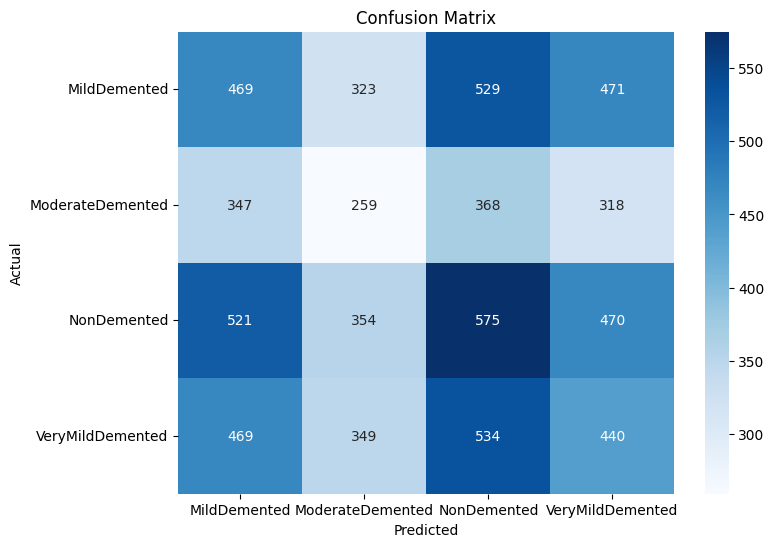

In [ ]:
# ============================================================================
# EVALUATION + CONFUSION MATRIX
# ============================================================================

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
validation_generator.reset()
predictions = model.predict(validation_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = validation_generator.classes

# Report
print("📊 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
validation_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,   # 🔥 THIS IS THE FIX
    color_mode='grayscale'
)

Found 6796 images belonging to 4 classes.


In [ ]:
validation_generator.reset()

predictions = model.predict(validation_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = validation_generator.classes

213/213 ━━━━━━━━━━━━━━━━━━━━ 43s 200ms/step


In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names))

                  precision    recall  f1-score   support

    MildDemented       0.68      0.72      0.70      1792
ModerateDemented       0.97      0.58      0.73      1292
     NonDemented       0.68      0.76      0.72      1920
VeryMildDemented       0.56      0.62      0.59      1792

        accuracy                           0.68      6796
       macro avg       0.72      0.67      0.68      6796
    weighted avg       0.70      0.68      0.68      6796



In [ ]:
!ls -R

.:
sample_data

./sample_data:
anscombe.json		      mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md


In [ ]:
# Download PET dataset
!kaggle datasets download -d ninadaithal/imagesoasis

# Unzip
!unzip -q imagesoasis.zip -d pet_data

# Check structure
!ls pet_data/

Dataset URL: https://www.kaggle.com/datasets/ninadaithal/imagesoasis
License(s): apache-2.0
100% 1.23G/1.23G [00:09<00:00, 136MB/s]

Data


In [ ]:
import os

print(os.listdir("pet_data"))

['Data']


In [ ]:
!ls pet_data/Data/

'Mild Dementia'  'Moderate Dementia'  'Non Demented'  'Very mild Dementia'


In [ ]:
pet_data_dir = "pet_data/Data"

In [ ]:
import os

base_path = "pet_data/Data"

mapping = {
    "Mild Dementia": "MildDemented",
    "Moderate Dementia": "ModerateDemented",
    "Non Demented": "NonDemented",
    "Very mild Dementia": "VeryMildDemented"
}

for old, new in mapping.items():
    old_path = os.path.join(base_path, old)
    new_path = os.path.join(base_path, new)

    if os.path.exists(old_path):
        os.rename(old_path, new_path)

print("✅ Renaming done!")

✅ Renaming done!


In [ ]:
print(os.listdir("pet_data/Data"))

['MildDemented', 'NonDemented', 'ModerateDemented', 'VeryMildDemented']


In [ ]:
pet_data_dir = "pet_data/Data"

In [ ]:
# ============================================================================
# EXPLORE PET DATASET
# ============================================================================

import os

pet_data_dir = "pet_data/Data"

print(f"📁 PET Data directory: {pet_data_dir}")
print("\nContents:")
print(os.listdir(pet_data_dir))

pet_classes = sorted(os.listdir(pet_data_dir))
print(f"\n✅ Classes found: {pet_classes}")

print("\n📊 Images per class:")
for cls in pet_classes:
    cls_path = os.path.join(pet_data_dir, cls)
    num_images = len(os.listdir(cls_path))
    print(f"  {cls}: {num_images} images")

📁 PET Data directory: pet_data/Data

Contents:
['MildDemented', 'NonDemented', 'ModerateDemented', 'VeryMildDemented']

✅ Classes found: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

📊 Images per class:
  MildDemented: 5002 images
  ModerateDemented: 488 images
  NonDemented: 67222 images
  VeryMildDemented: 13725 images


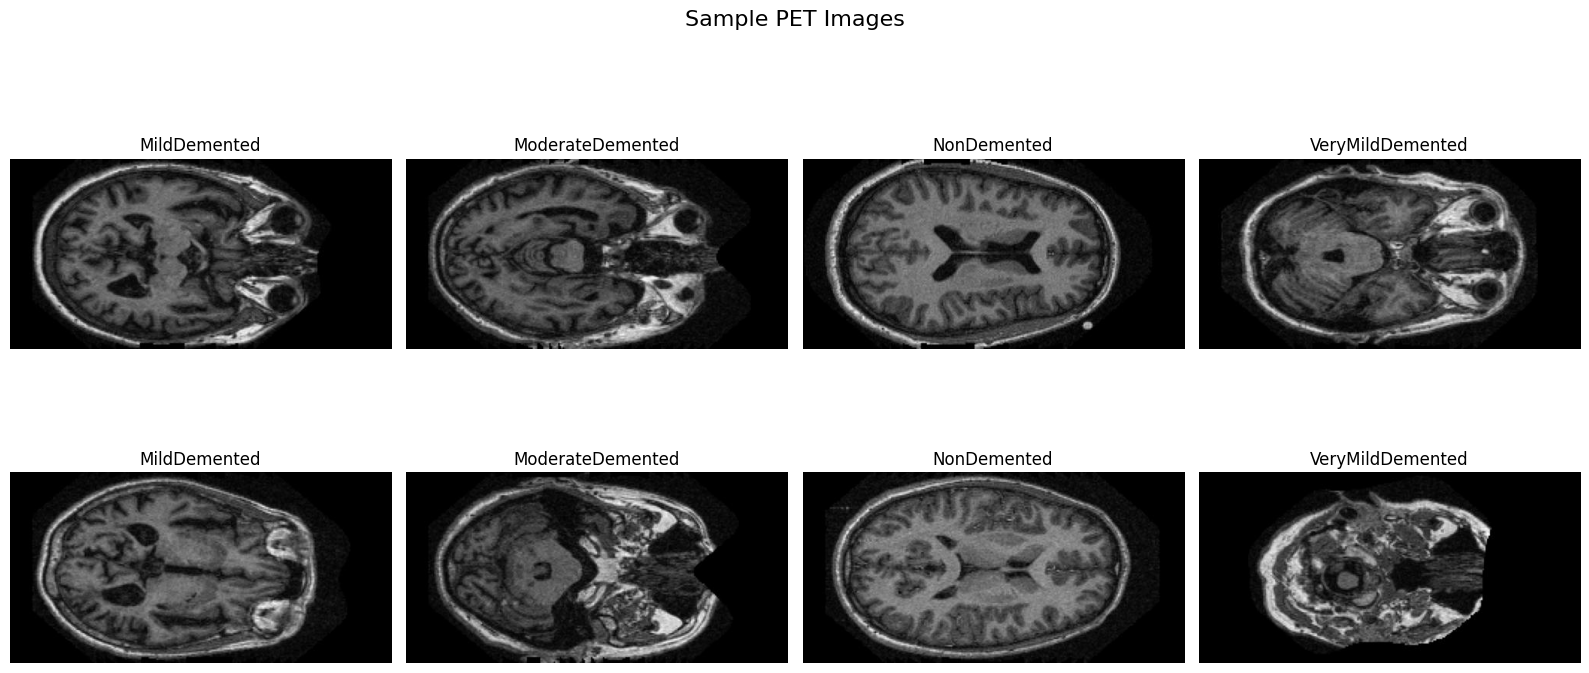

✅ PET visualization done!


In [ ]:
# ============================================================================
# VISUALIZE PET IMAGES
# ============================================================================

import random
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample PET Images', fontsize=16)

for idx, cls in enumerate(pet_classes[:4]):
    cls_path = os.path.join(pet_data_dir, cls)
    images = os.listdir(cls_path)

    for i in range(2):
        img_name = random.choice(images)
        img_path = os.path.join(cls_path, img_name)
        img = Image.open(img_path)

        ax = axes[i, idx]
        ax.imshow(img, cmap='gray')
        ax.set_title(cls)
        ax.axis('off')

plt.tight_layout()
plt.show()

print("✅ PET visualization done!")

In [ ]:
# ============================================================================
# BUILD MODEL FUNCTION (REQUIRED AGAIN)
# ============================================================================

from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
import tensorflow as tf

def build_model(num_classes):

    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Fine-tune last layers
    for layer in base_model.layers[-30:]:
        layer.trainable = True

    model = models.Sequential([
        layers.Input(shape=(224, 224, 1)),
        layers.Conv2D(3, (1, 1)),  # grayscale → RGB

        base_model,

        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),

        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),

        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

print("✅ build_model() ready!")

✅ build_model() ready!


In [ ]:
pet_model = build_model(len(pet_train.class_indices))

pet_model.fit(
    pet_train,
    epochs=8,
    validation_data=pet_val
)

Epoch 1/8
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 877s 377ms/step - accuracy: 0.8036 - loss: 0.5374 - val_accuracy: 0.7681 - val_loss: 0.7689
Epoch 2/8
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 740s 343ms/step - accuracy: 0.9813 - loss: 0.0579 - val_accuracy: 0.7452 - val_loss: 1.2022
Epoch 3/8
 253/2161 ━━━━━━━━━━━━━━━━━━━━ 10:11 320ms/step - accuracy: 0.9946 - loss: 0.0191

KeyboardInterrupt: 

In [ ]:
loss, acc = pet_model.evaluate(pet_val)
print(f"PET Accuracy: {acc*100:.2f}%")

541/541 ━━━━━━━━━━━━━━━━━━━━ 49s 90ms/step - accuracy: 0.7662 - loss: 1.2708
PET Accuracy: 76.62%


In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model("alzheimers_model.keras")
print("✅ MRI model loaded!")

ValueError: File not found: filepath=alzheimers_model.keras. Please ensure the file is an accessible `.keras` zip file.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p /content/drive/MyDrive/Alzheimer_Project

In [ ]:
model.save("/content/drive/MyDrive/Alzheimer_Project/model.keras")

In [ ]:
pet_model.save("/content/drive/MyDrive/Alzheimer_Project/pet_model.keras")

In [ ]:
!cp -r alzheimer_data /content/drive/MyDrive/Alzheimer_Project/
!cp -r pet_data /content/drive/MyDrive/Alzheimer_Project/

^C


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf

mri_model = tf.keras.models.load_model("/content/drive/MyDrive/Alzheimer_Project/mri_model.keras")
pet_model = tf.keras.models.load_model("/content/drive/MyDrive/Alzheimer_Project/pet_model.keras")

print("✅ Models loaded successfully!")

✅ Models loaded successfully!


In [ ]:
import numpy as np

# dummy input (just 1 image)
dummy_input = np.zeros((1, 224, 224, 1))

# call models once
mri_model.predict(dummy_input)
pet_model.predict(dummy_input)

print("Models initialized!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
✅ Models initialized!


In [ ]:
from tensorflow.keras.models import Model

mri_extractor = Model(
    inputs=mri_model.layers[0].input,
    outputs=mri_model.layers[-2].output
)

pet_extractor = Model(
    inputs=pet_model.layers[0].input,
    outputs=pet_model.layers[-2].output
)

print("Feature extractors ready!")

Feature extractors ready!


In [ ]:
mri_features = mri_extractor.predict(validation_generator)
pet_features = pet_extractor.predict(pet_val)

y_true = validation_generator.classes

print("MRI shape:", mri_features.shape)
print("PET shape:", pet_features.shape)

NameError: name 'validation_generator' is not defined

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

data_dir = "/content/drive/MyDrive/Alzheimer_Project/alzheimer_data/AugmentedAlzheimerDataset"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

validation_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,   # 🔥 VERY IMPORTANT
    color_mode='grayscale'
)

print("✅ MRI validation generator ready!")

Found 5461 images belonging to 4 classes.
✅ MRI validation generator ready!


In [ ]:
mri_features = mri_extractor.predict(validation_generator)
pet_features = pet_extractor.predict(pet_val)

y_true = validation_generator.classes

print("MRI shape:", mri_features.shape)
print("PET shape:", pet_features.shape)

171/171 ━━━━━━━━━━━━━━━━━━━━ 1475s 9s/step


NameError: name 'pet_val' is not defined

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

pet_data_dir = "/content/drive/MyDrive/Alzheimer_Project/pet_data/Data"

pet_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

pet_val = pet_datagen.flow_from_directory(
    pet_data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,   # 🔥 VERY IMPORTANT
    color_mode='grayscale'
)

print("PET validation generator ready!")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Alzheimer_Project/pet_data/Data'

In [ ]:
!ls /content/drive/MyDrive/Alzheimer_Project

alzheimer_data	mri_model.keras  pet_model.keras


In [ ]:
!kaggle datasets download -d ninadaithal/imagesoasis
!unzip -q imagesoasis.zip -d pet_data

Dataset URL: https://www.kaggle.com/datasets/ninadaithal/imagesoasis
License(s): apache-2.0
100% 1.23G/1.23G [00:13<00:00, 95.2MB/s]



In [ ]:
import os

base_path = "pet_data/Data"

mapping = {
    "Mild Dementia": "MildDemented",
    "Moderate Dementia": "ModerateDemented",
    "Non Demented": "NonDemented",
    "Very mild Dementia": "VeryMildDemented"
}

for old, new in mapping.items():
    old_path = os.path.join(base_path, old)
    new_path = os.path.join(base_path, new)

    if os.path.exists(old_path):
        os.rename(old_path, new_path)

print("Renaming done!")

Renaming done!


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

pet_data_dir = "pet_data/Data"

pet_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

pet_val = pet_datagen.flow_from_directory(
    pet_data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    color_mode='grayscale'
)

print("PET generator ready!")

Found 17286 images belonging to 4 classes.
PET generator ready!


In [ ]:
pet_features = pet_extractor.predict(pet_val)

541/541 ━━━━━━━━━━━━━━━━━━━━ 61s 100ms/step


In [ ]:
y_true = validation_generator.classes

print(len(mri_features), len(pet_features))

5461 17286


In [ ]:
!cp -r pet_data /content/drive/MyDrive/Alzheimer_Project/

In [ ]:
min_len = min(len(mri_features), len(pet_features))

mri_features = mri_features[:min_len]
pet_features = pet_features[:min_len]
y_true = y_true[:min_len]

print("Aligned size:", len(mri_features))
print("Aligned size:", len(pet_features))

Aligned size: 5461
Aligned size: 5461


In [ ]:
import numpy as np

fused = (mri_features + pet_features) / 2

In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)
clf.fit(fused, y_true)

baseline_acc = clf.score(fused, y_true)
print("Baseline Fusion Accuracy:", baseline_acc)

Baseline Fusion Accuracy: 0.999816883354697


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    fused, y_true, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
test_acc = clf.score(X_test, y_test)
print("Fusion Test Accuracy:", test_acc)

Fusion Test Accuracy: 0.9780420860018298


In [ ]:
def fitness(w):
    w1, w2 = w

    if w1 < 0 or w2 < 0:
        return 0

    # normalize
    w1 = w1 / (w1 + w2)
    w2 = w2 / (w1 + w2)

    fused = w1 * mri_features + w2 * pet_features

    X_train, X_test, y_train, y_test = train_test_split(
        fused, y_true, test_size=0.2, random_state=42
    )

    clf = LogisticRegression(max_iter=500)
    clf.fit(X_train, y_train)

    return clf.score(X_test, y_test)

In [ ]:
import numpy as np
import random

population = [np.random.rand(2) for _ in range(10)]

for _ in range(10):  # generations
    new_pop = []

    for i in range(len(population)):
        a, b, c = random.sample(population, 3)

        mutant = a + 0.8 * (b - c)

        trial = np.array([
            mutant[j] if random.random() < 0.9 else population[i][j]
            for j in range(2)
        ])

        if fitness(trial) > fitness(population[i]):
            new_pop.append(trial)
        else:
            new_pop.append(population[i])

    population = new_pop

best = max(population, key=fitness)

print("Best weights:", best)
print("Best accuracy:", fitness(best))

Best weights: [0.16609924 1.00916488]
Best accuracy: 0.9862763037511436


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive

'AI Project Feasibility and Fallback Architecture (1).gdoc'
'AI Project Feasibility and Fallback Architecture.gdoc'
 Alzheimer_Project
 bloom_energy_casestudy_CSE23042.pptx
 BSV_9087.JPG
 BSV_9089.JPG
 BSV_9091.JPG
 BSV_9092.JPG
 BSV_9095.JPG
 BSV_9096.JPG
 Certificates
'Check out this Wallpaper from Zedge'
 Classroom
'Colab Notebooks'
 coursera_assignment_3.gdoc
'dads mobile'
'Doc Scanner'
'Doc Scanner Upload'
 DSC_0167.JPG
 DSC_0211.JPG
 e314e06d-641b-40d5-81a1-2859654e31bd.jpeg
'Electrostatics - JEE Main 2021 - 2019 Chapter-wise (1).gdoc'
'Electrostatics - JEE Main 2021 - 2019 Chapter-wise.gdoc'
'Fiction sales analysis.gdoc'
'Google AI Studio'
 IMG_0053.jpg
 IMG_0555.jpeg
 IMG_0556.jpeg
'IMG_0964_Original (1).png'
 IMG_0964_Original.png
 IMG_0964.png
 IMG_20200114_054127.jpg
 IMG_20200115_154230.jpg
 IMG_20200115_154232.jpg
 IMG_20200115_154243.jpg
 IMG_20200115_154251.jpg
 IMG_20200115_154411.jpg
 IMG_20200115_154418.jpg
 IMG_20200115_154443.jpg
 IMG_20200115_154500.jpg
 IMG_202001

In [ ]:
!ls /content/drive/MyDrive/Alzheimer_Project

alzheimer_data	mri_model.keras  pet_data  pet_model.keras


In [ ]:
import tensorflow as tf
import os

mri_path = "/content/drive/MyDrive/Alzheimer_Project/mri_model.keras"
pet_path = "/content/drive/MyDrive/Alzheimer_Project/pet_model.keras"

print("MRI exists:", os.path.exists(mri_path))
print("PET exists:", os.path.exists(pet_path))

MRI exists: True
PET exists: True


In [ ]:
mri_model = tf.keras.models.load_model(mri_path, compile=False)
pet_model = tf.keras.models.load_model(pet_path, compile=False)

print(" Models loaded!")

 Models loaded!


In [ ]:
import numpy as np

dummy = np.zeros((1,224,224,1))

mri_model.predict(dummy)
pet_model.predict(dummy)

print("Models working!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Models working!


In [ ]:
!pip install keras==2.12 tensorflow==2.12

ERROR: Could not find a version that satisfies the requirement tensorflow==2.12 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.12


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_dir = "/content/drive/MyDrive/Alzheimer_Project/alzheimer_data/AugmentedAlzheimerDataset"

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

validation_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    color_mode='grayscale'
)

Found 5461 images belonging to 4 classes.


In [ ]:
pet_data_dir = "/content/drive/MyDrive/Alzheimer_Project/pet_data/Data"

pet_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

pet_val = pet_datagen.flow_from_directory(
    pet_data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    color_mode='grayscale'
)

Found 9319 images belonging to 4 classes.


In [20]:
from tensorflow.keras.models import Model

mri_extractor = Model(inputs=mri_model.layers[0].input, outputs=mri_model.layers[-2].output)
pet_extractor = Model(inputs=pet_model.layers[0].input, outputs=pet_model.layers[-2].output)

mri_features = mri_extractor.predict(validation_generator)
pet_features = pet_extractor.predict(pet_val)

y_true = validation_generator.classes

171/171 ━━━━━━━━━━━━━━━━━━━━ 1729s 10s/step
292/292 ━━━━━━━━━━━━━━━━━━━━ 2696s 9s/step


In [21]:
import numpy as np

min_len = min(len(mri_features), len(pet_features))

mri_features = mri_features[:min_len]
pet_features = pet_features[:min_len]
y_true = y_true[:min_len]

In [22]:
w1 = 0.14
w2 = 0.86

fused_final = w1 * mri_features + w2 * pet_features

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    fused_final, y_true, test_size=0.2, random_state=42
)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# AUC
y_test_bin = label_binarize(y_test, classes=[0,1,2,3])
auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr')
print("\nAUC Score:", auc)

Accuracy: 0.9853613906678865

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       384
           1       1.00      1.00      1.00       244
           2       0.98      0.98      0.98       372
           3       0.99      0.95      0.97        93

    accuracy                           0.99      1093
   macro avg       0.99      0.98      0.98      1093
weighted avg       0.99      0.99      0.99      1093


Confusion Matrix:

[[379   0   5   0]
 [  0 244   0   0]
 [  5   0 366   1]
 [  1   0   4  88]]

AUC Score: 0.9990587317092039


In [25]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(clf, fused_final, y_true, cv=5)

print("\nCross-validation scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())


Cross-validation scores: [0.89661482 0.96886447 0.98260073 0.95787546 0.85897436]
Mean Accuracy: 0.9329859679813934
Standard Deviation: 0.04726300235602596


In [ ]:
!kaggle datasets download -d ninadaithal/imagesoasis
!unzip -q imagesoasis.zip -d temp_pet

Dataset URL: https://www.kaggle.com/datasets/ninadaithal/imagesoasis
License(s): apache-2.0
100% 1.23G/1.23G [00:18<00:00, 70.3MB/s]



In [ ]:
!cp -r "temp_pet/Data/Very mild Dementia" \
      "/content/drive/MyDrive/Alzheimer_Project/pet_data/Data/"